In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [ ]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

Mean I to E weight: 0.003


/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:629: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [05:12<00:00,  2.69it/s]


Mean I to E weight: 0.005999999999999999


100%|██████████| 840/840 [05:04<00:00,  2.76it/s]


Mean I to E weight: 0.009


100%|██████████| 840/840 [04:40<00:00,  3.00it/s]


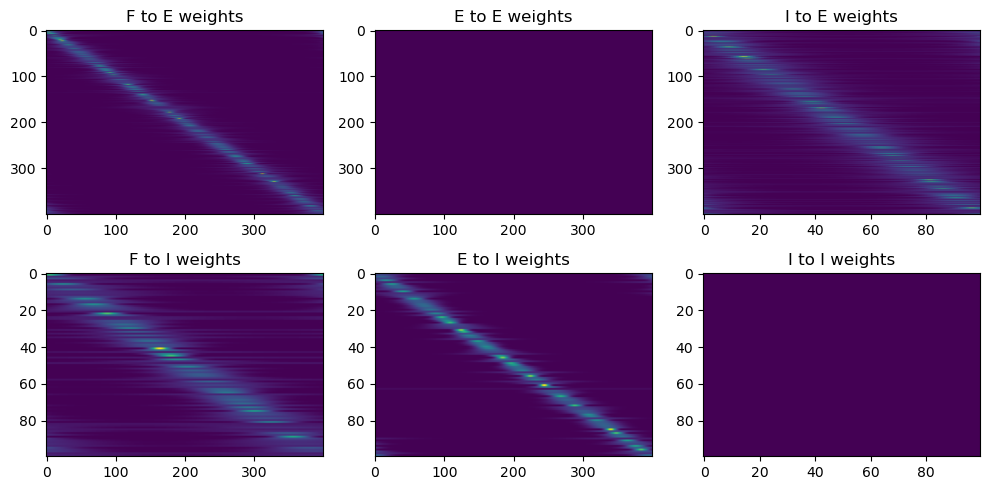

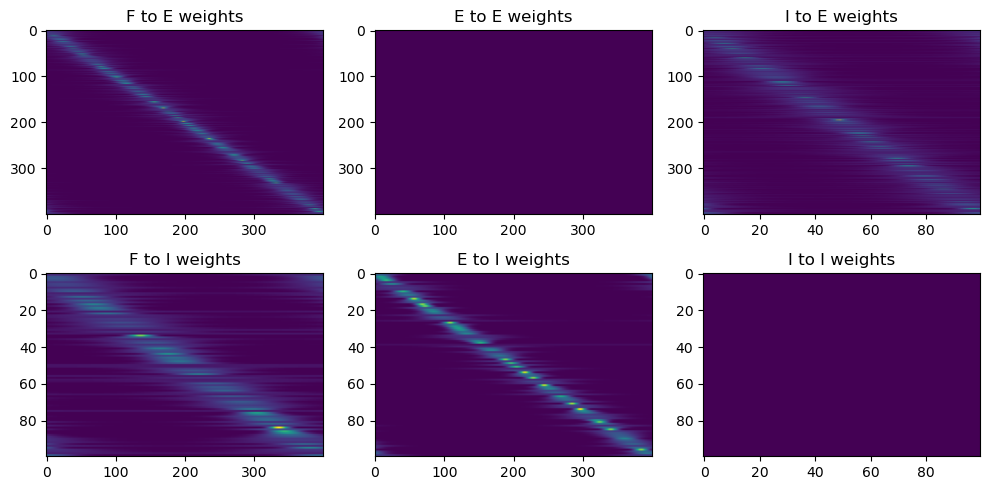

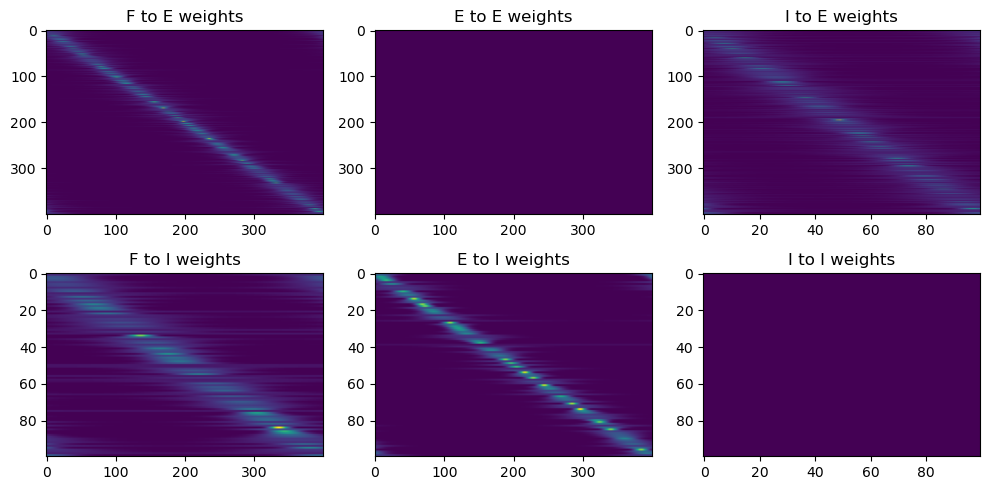

In [3]:
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.3, E_to_I_scale=0.2)
net_inh_1.run()

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.6, E_to_I_scale=0.2)
net_inh_2.run()

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.9, E_to_I_scale=0.2)
net_inh_3.run()

In [4]:
drift_mag_1, drift_rate_1, convergence_1 = net_inh_1.get_drift_metrics()
drift_mag_2, drift_rate_2, convergence_2 = net_inh_2.get_drift_metrics()
drift_mag_3, drift_rate_3, convergence_3 = net_inh_3.get_drift_metrics()

(-1.0, 5.0)

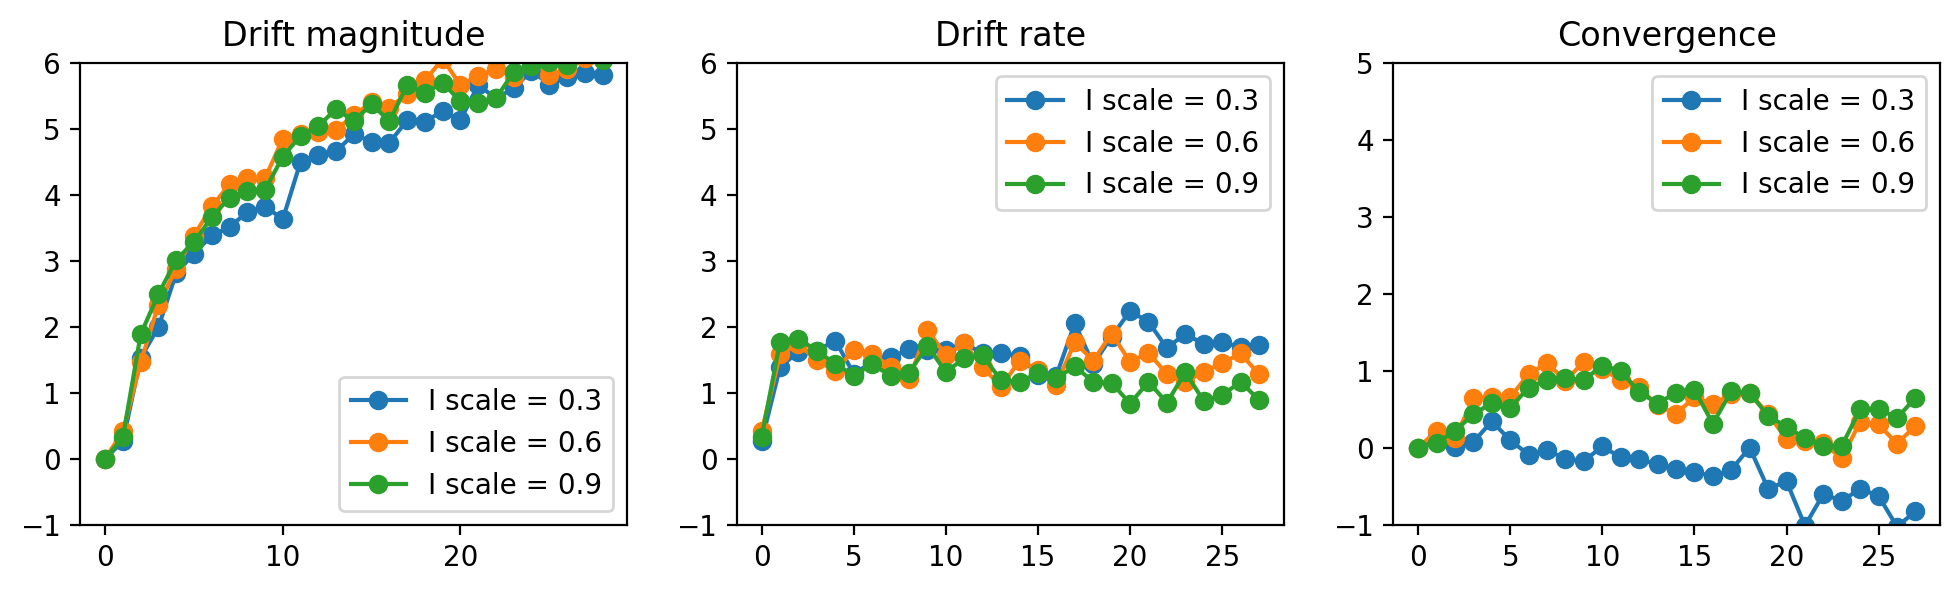

In [6]:
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200)
axs[0].plot(np.nanmean(drift_mag_1, axis=1), marker='o', label="I scale = 0.3")
axs[0].plot(np.nanmean(drift_mag_2, axis=1), marker='o', label="I scale = 0.6")
axs[0].plot(np.nanmean(drift_mag_3, axis=1), marker='o', label="I scale = 0.9")
axs[0].set_title("Drift magnitude")
axs[0].legend()
axs[0].set_ylim([-1, 6])


axs[1].plot(np.nanmean(drift_rate_1, axis=1), marker='o', label="I scale = 0.3")
axs[1].plot(np.nanmean(drift_rate_2, axis=1), marker='o', label="I scale = 0.6")
axs[1].plot(np.nanmean(drift_rate_3, axis=1), marker='o', label="I scale = 0.9")
axs[1].set_title("Drift rate")
axs[1].legend()
axs[1].set_ylim([-1, 6])

axs[2].plot(np.nanmean(convergence_1, axis=1), marker='o', label="I scale = 0.3")
axs[2].plot(np.nanmean(convergence_2, axis=1), marker='o', label="I scale = 0.6")
axs[2].plot(np.nanmean(convergence_3, axis=1), marker='o', label="I scale = 0.9")
axs[2].set_title("Convergence")
axs[2].legend()
axs[2].set_ylim([-1, 5])


In [ ]:
activity_1 = net_inh_1.estimate_activity_at_day(90, 10)
activity_2 = net_inh_2.estimate_activity_at_day(90, 10)
activity_3 = net_inh_3.estimate_activity_at_day(90, 10)

In [ ]:
activity_1 = activity_1[0]
activity_2 = activity_2[0]
activity_3 = activity_3[0]

In [ ]:
plt.figure(dpi=200, figsize=(12,4))
plt.plot(activity_1, marker='o', label="I scale = 0.3")
plt.plot(activity_2, marker='o', label="I scale = 0.6")
plt.plot(activity_3, marker='o', label="I scale = 0.9")
plt.title("Estimated activity at day 10, ") 

In [ ]:
initial_tuning_widths_1 = net_inh_1.estimate_tuning_widths_at_day(0)
initial_tuning_widths_2 = net_inh_2.estimate_tuning_widths_at_day(0)
initial_tuning_widths_3 = net_inh_3.estimate_tuning_widths_at_day(0)

fig, axs = plt.subplots(1, 3, figsize=(18, 4), dpi=200)
axs[0].hist(initial_tuning_widths_1, bins=20, color='blue', alpha=0.7)
axs[0].set_title('Tuning Widths at Day 0 (I scale = 0.3)')
axs[0].set_xlabel('Tuning Width at Day 0')
axs[0].set_ylabel('Number of Neurons')

axs[1].hist(initial_tuning_widths_2, bins=20, color='orange', alpha=0.7)
axs[1].set_title('Tuning Widths at Day 0 (I scale = 0.6)')
axs[1].set_xlabel('Tuning Width at Day 0')  
axs[1].set_ylabel('Number of Neurons')

axs[2].hist(initial_tuning_widths_3, bins=20, color='green', alpha=0.7)
axs[2].set_title('Tuning Widths at Day 0 (I scale = 0.9)')
axs[2].set_xlabel('Tuning Width at Day 0')  
axs[2].set_ylabel('Number of Neurons')
plt.tight_layout()
plt.show()

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_72427/3805885358.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_72427/3805885358.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_72427/3805885358.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


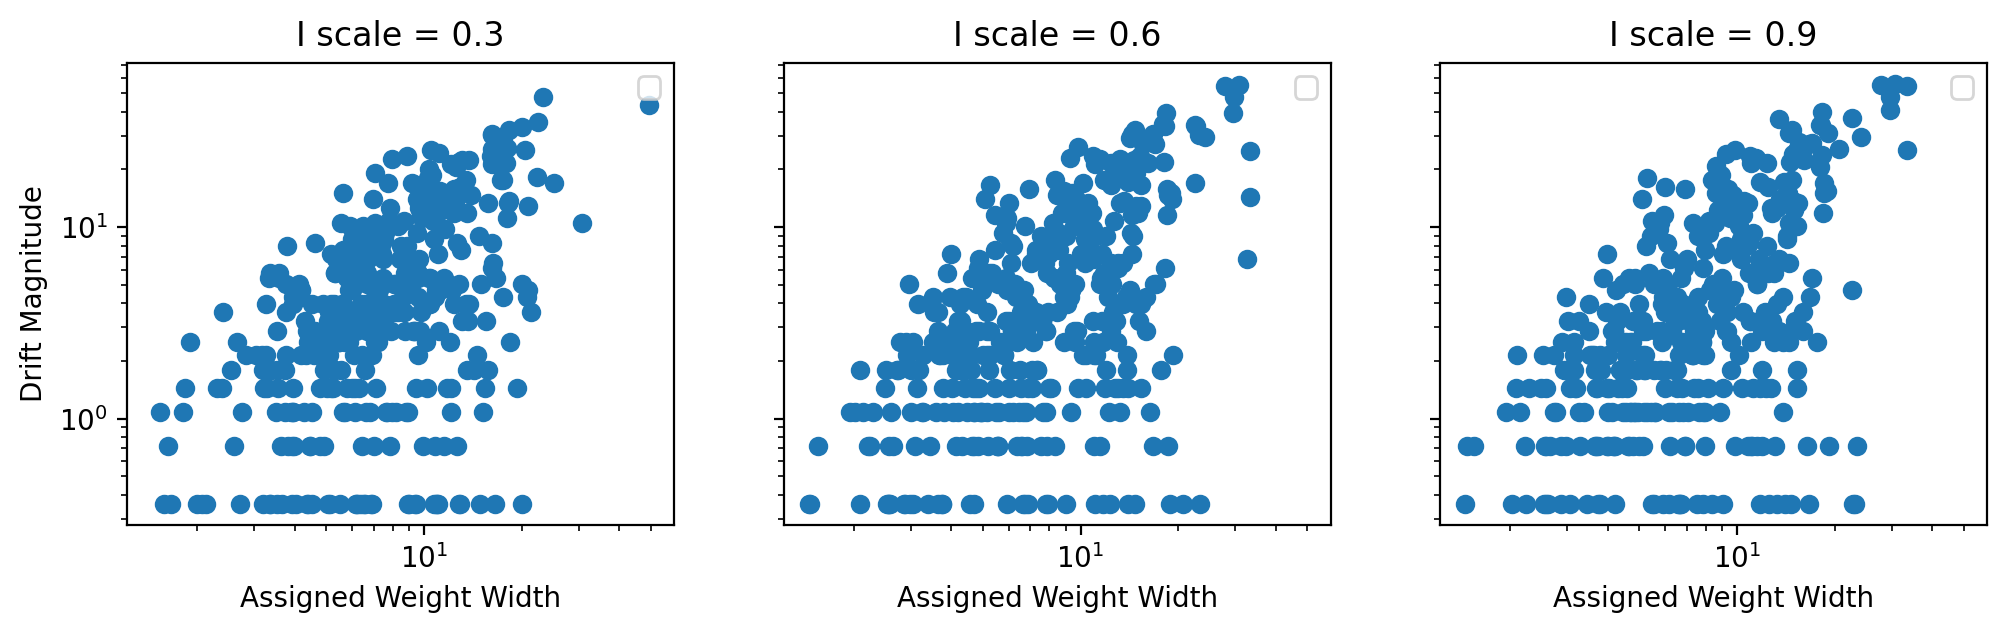

In [ ]:
# plot drift magnitude vs assigned weight width (vars_ef)
 
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200, sharex=True, sharey=True)

axs[0].scatter(net_inh_1.vars_ef, drift_mag_1[-1], alpha=0.7)
axs[0].set_xlabel("Assigned Weight Width")
axs[0].set_ylabel("Drift Magnitude")
axs[0].set_title("I scale = 0.3")
axs[0].legend()
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].scatter(net_inh_2.vars_ef, drift_mag_2[-1], alpha=0.7)
axs[1].set_xlabel("Assigned Weight Width")
axs[1].set_title("I scale = 0.6")
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[2].scatter(net_inh_3.vars_ef, drift_mag_3[-1], alpha=0.7)
axs[2].set_xlabel("Assigned Weight Width") 
axs[2].set_title("I scale = 0.9")
axs[2].legend()
axs[2].set_xscale('log')
axs[2].set_yscale('log')


